# Ottermap Turf Detection Validation Notebook

Use this notebook to check one step at a time: load data, rasterize labels, and visually inspect overlays before moving on to tiling or training.

In [10]:
import matplotlib.pyplot as plt
import numpy as np

from src.load_data import load_image_and_labels
from src.geoutils import rasterize_geometry
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['image.cmap'] = 'gray'

## Step 1: Load the first sample

This checks whether the TIFF georeferencing and GeoJSON labels are being read correctly.

In [17]:
img, geoms, transform, crs, (h, w) = load_image_and_labels('data/raw/3.tiff', 'data/raw/3.geojson')
print('image shape:', img.shape)
print('image dtype:', img.dtype)
print('crs:', crs)
print('transform:', transform)
print('top-left geo:', transform * (0, 0))
print('bottom-right geo:', transform * (w, h))
print('polygon count:', len(geoms) if isinstance(geoms, list) else 1)

Loaded data/raw/3.tiff: 5906x5429, CRS=EPSG:4326
Loaded data/raw/3.geojson: 16 polygons
image shape: (5429, 5906, 3)
image dtype: uint8
crs: EPSG:4326
transform: | 0.00, 0.00,-78.71|
| 0.00,-0.00, 33.85|
| 0.00, 0.00, 1.00|
top-left geo: (-78.71052009237394, 33.845330772705424)
bottom-right geo: (-78.70655969678269, 33.8423069819284)
polygon count: 16


## Step 2: Rasterize the mask

This converts the GeoJSON polygons into a binary mask aligned with the image.

In [18]:
mask = rasterize_geometry(geoms, {'height': h, 'width': w, 'rio_transform': transform}, value=1)
print('mask shape:', mask.shape)
print('mask unique values:', sorted(set(mask.flatten().tolist())))
print('mask sum:', int(mask.sum()))

mask shape: (5429, 5906)
mask unique values: [0, 1]
mask sum: 13565073


## Step 3: Visualize image, mask, and overlay

This is the most important validation step. The mask should land on turf only.

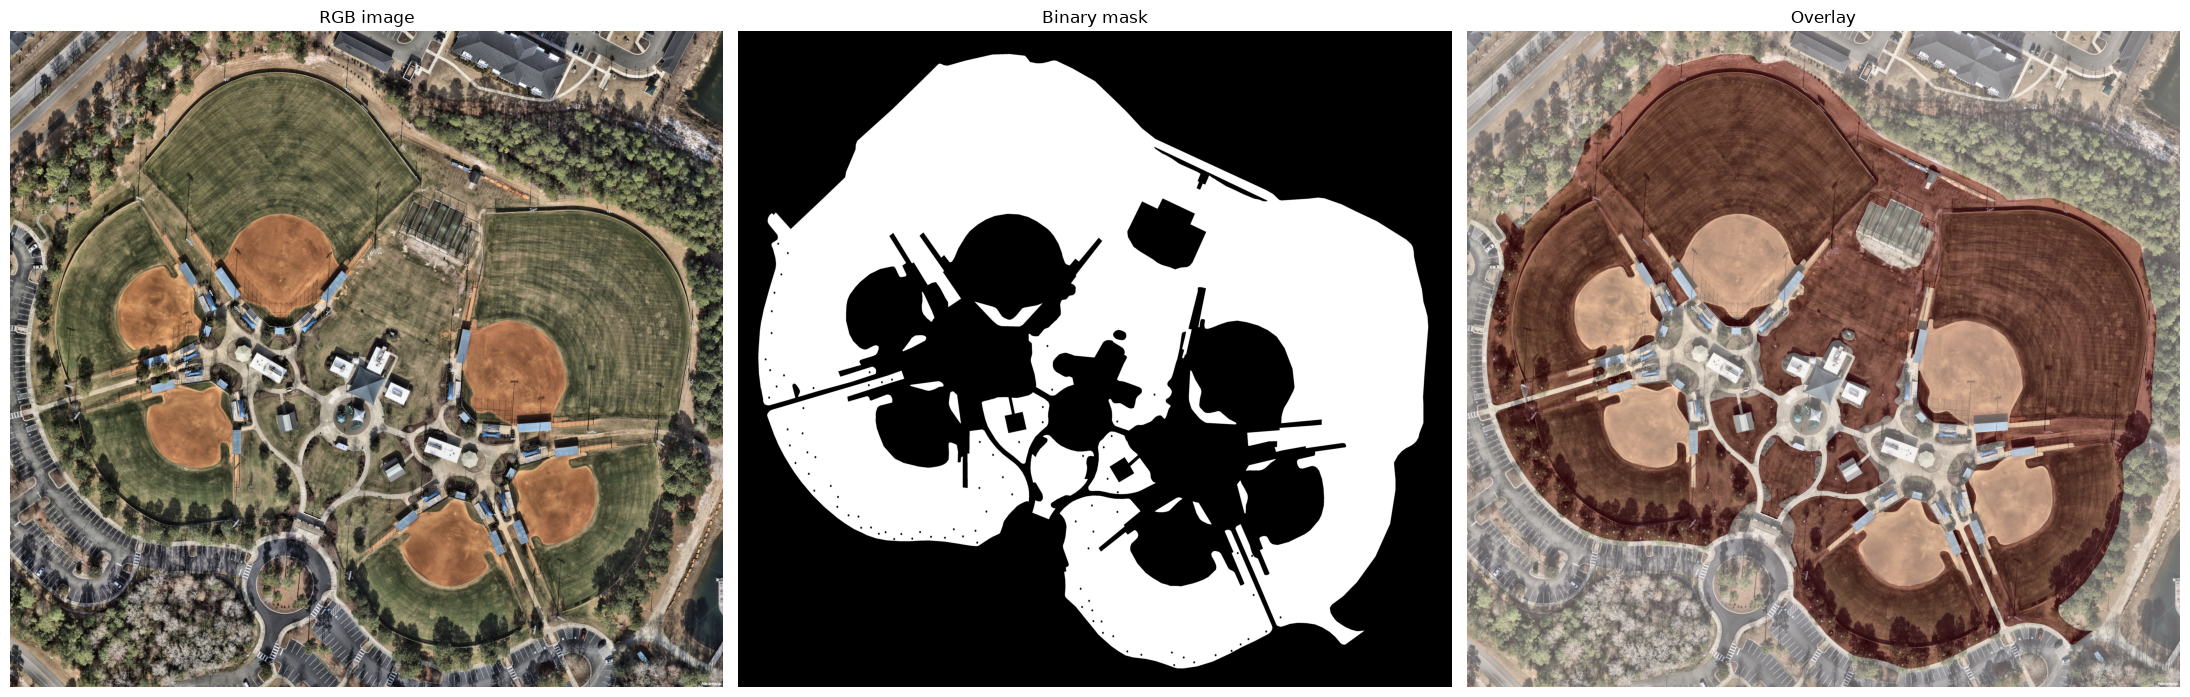

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

axes[0].imshow(img)
axes[0].set_title('RGB image')
axes[0].axis('off')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Binary mask')
axes[1].axis('off')

axes[2].imshow(img)
axes[2].imshow(mask, alpha=0.35, cmap='Reds')
axes[2].set_title('Overlay')
axes[2].axis('off')

plt.tight_layout()

## Step 4: Repeat on a second sample

Use a second image to confirm the pipeline is not only working on one example.

## Step 5: Inspect one generated tile

Now check that tiling preserved the alignment between the image tile and its mask tile.

In [ ]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

manifest = json.loads(Path('data/tiles_smoke/manifest.json').read_text())
first_tile = manifest[0]

img_tile = cv2.cvtColor(cv2.imread(first_tile['image_path']), cv2.COLOR_BGR2RGB)
mask_tile = cv2.imread(first_tile['mask_path'], cv2.IMREAD_GRAYSCALE)

print('tile id:', first_tile['tile_id'])
print('tile split:', first_tile['split'])
print('tile image shape:', img_tile.shape)
print('tile mask shape:', mask_tile.shape)
print('tile mask unique:', sorted(set(mask_tile.flatten().tolist())))

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
axes[0].imshow(img_tile)
axes[0].set_title('Tile RGB')
axes[0].axis('off')
axes[1].imshow(mask_tile, cmap='gray')
axes[1].set_title('Tile mask')
axes[1].axis('off')
axes[2].imshow(img_tile)
axes[2].imshow(mask_tile, alpha=0.35, cmap='Reds')
axes[2].set_title('Tile overlay')
axes[2].axis('off')
plt.tight_layout()

## Step 6: Load a dataset batch

This checks the training input pipeline end to end: tiles, augmentation, tensor shapes, and mask values.

In [ ]:
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from src.dataset import TurfDataset

dataset = TurfDataset('data/tiles_smoke/manifest.json', split='train')
loader = DataLoader(dataset, batch_size=2, shuffle=False)

images, masks, tile_ids = next(iter(loader))
print('dataset length:', len(dataset))
print('batch image shape:', images.shape)
print('batch mask shape:', masks.shape)
print('batch image dtype:', images.dtype)
print('batch mask dtype:', masks.dtype)
print('batch image min/max:', float(images.min()), float(images.max()))
print('batch mask min/max:', float(masks.min()), float(masks.max()))
print('tile ids:', tile_ids)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
for i in range(min(2, images.shape[0])):
    image_np = images[i].permute(1, 2, 0).numpy()
    image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image_np = np.clip(image_np, 0, 1)
    mask_np = masks[i, 0].numpy()

    axes[i * 2].imshow(image_np)
    axes[i * 2].set_title(f'Batch image {i}')
    axes[i * 2].axis('off')

    axes[i * 2 + 1].imshow(image_np)
    axes[i * 2 + 1].imshow(mask_np, alpha=0.35, cmap='Reds')
    axes[i * 2 + 1].set_title(f'Batch overlay {i}')
    axes[i * 2 + 1].axis('off')

plt.tight_layout()

In [ ]:
img2, geoms2, transform2, crs2, (h2, w2) = load_image_and_labels('data/raw/2.tiff', 'data/raw/2.geojson')
mask2 = rasterize_geometry(geoms2, {'height': h2, 'width': w2, 'rio_transform': transform2}, value=1)

print('image 2 shape:', img2.shape)
print('image 2 crs:', crs2)
print('image 2 transform:', transform2)
print('image 2 polygon count:', len(geoms2) if isinstance(geoms2, list) else 1)

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
axes[0].imshow(img2)
axes[0].set_title('RGB image 2')
axes[0].axis('off')
axes[1].imshow(mask2, cmap='gray')
axes[1].set_title('Binary mask 2')
axes[1].axis('off')
axes[2].imshow(img2)
axes[2].imshow(mask2, alpha=0.35, cmap='Reds')
axes[2].set_title('Overlay 2')
axes[2].axis('off')
plt.tight_layout()

In [ ]:
import json
from pathlib import Path

import cv2

manifest = json.loads(Path('data/tiles_smoke/manifest.json').read_text())
first_tile = manifest[0]

img_tile = cv2.cvtColor(cv2.imread(first_tile['image_path']), cv2.COLOR_BGR2RGB)
mask_tile = cv2.imread(first_tile['mask_path'], cv2.IMREAD_GRAYSCALE)

print('tile id:', first_tile['tile_id'])
print('tile split:', first_tile['split'])
print('tile image shape:', img_tile.shape)
print('tile mask shape:', mask_tile.shape)
print('tile mask unique:', sorted(set(mask_tile.flatten().tolist())))

fig, axes = plt.subplots(1, 3, figsize=(22, 8))
axes[0].imshow(img_tile)
axes[0].set_title('Tile RGB')
axes[0].axis('off')
axes[1].imshow(mask_tile, cmap='gray')
axes[1].set_title('Tile mask')
axes[1].axis('off')
axes[2].imshow(img_tile)
axes[2].imshow(mask_tile, alpha=0.35, cmap='Reds')
axes[2].set_title('Tile overlay')
axes[2].axis('off')
plt.tight_layout()

In [ ]:
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from src.dataset import TurfDataset

dataset = TurfDataset('data/tiles_smoke/manifest.json', split='train')
loader = DataLoader(dataset, batch_size=2, shuffle=False)

images, masks, tile_ids = next(iter(loader))
print('dataset length:', len(dataset))
print('batch image shape:', images.shape)
print('batch mask shape:', masks.shape)
print('batch image dtype:', images.dtype)
print('batch mask dtype:', masks.dtype)
print('batch image min/max:', float(images.min()), float(images.max()))
print('batch mask min/max:', float(masks.min()), float(masks.max()))
print('tile ids:', tile_ids)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()
for i in range(min(2, images.shape[0])):
    image_np = images[i].permute(1, 2, 0).numpy()
    image_np = image_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    image_np = np.clip(image_np, 0, 1)
    mask_np = masks[i, 0].numpy()

    axes[i * 2].imshow(image_np)
    axes[i * 2].set_title(f'Batch image {i}')
    axes[i * 2].axis('off')

    axes[i * 2 + 1].imshow(image_np)
    axes[i * 2 + 1].imshow(mask_np, alpha=0.35, cmap='Reds')
    axes[i * 2 + 1].set_title(f'Batch overlay {i}')
    axes[i * 2 + 1].axis('off')

plt.tight_layout()